<a href="https://colab.research.google.com/github/lakmg2007/SCALAR_LEARNINGS/blob/main/C02_EMISSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Goal:**
The objective is to analyze vehicle characteristics influencing CO₂ emissions and build a regression model capable of estimating emissions using vehicle specifications and fuel consumption data.

In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [38]:
df = pd.read_csv("CO2_Emissions.csv")
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [39]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [40]:
df.isnull().sum()

,0
Make,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


In [24]:
df.duplicated().sum()

np.int64(1103)

In [41]:
df.dtypes

,0
Make,object
Model,object
Vehicle Class,object
Engine Size(L),float64
Cylinders,int64
Transmission,object
Fuel Type,object
Fuel Consumption City (L/100 km),float64
Fuel Consumption Hwy (L/100 km),float64
Fuel Consumption Comb (L/100 km),float64


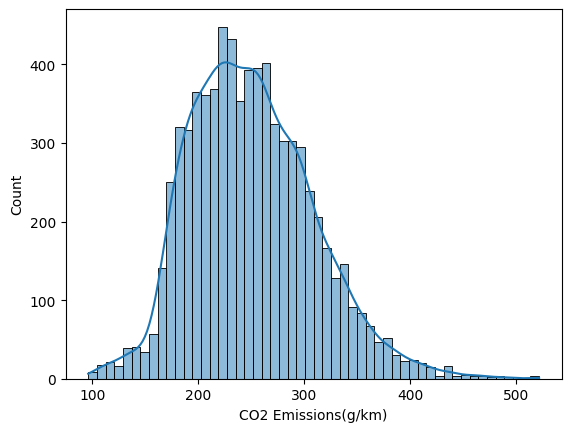

In [42]:
sns.histplot(df['CO2 Emissions(g/km)'], kde=True)
plt.show()

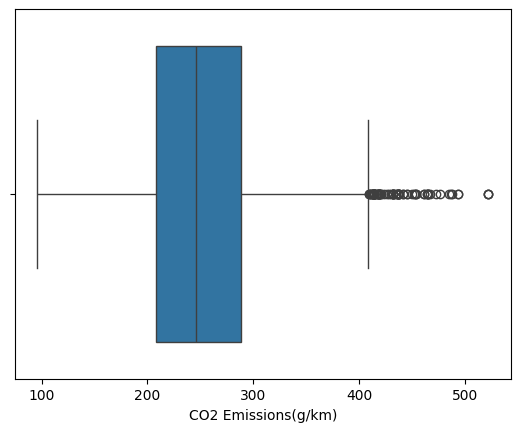

In [43]:
sns.boxplot(x=df['CO2 Emissions(g/km)'])
plt.show()

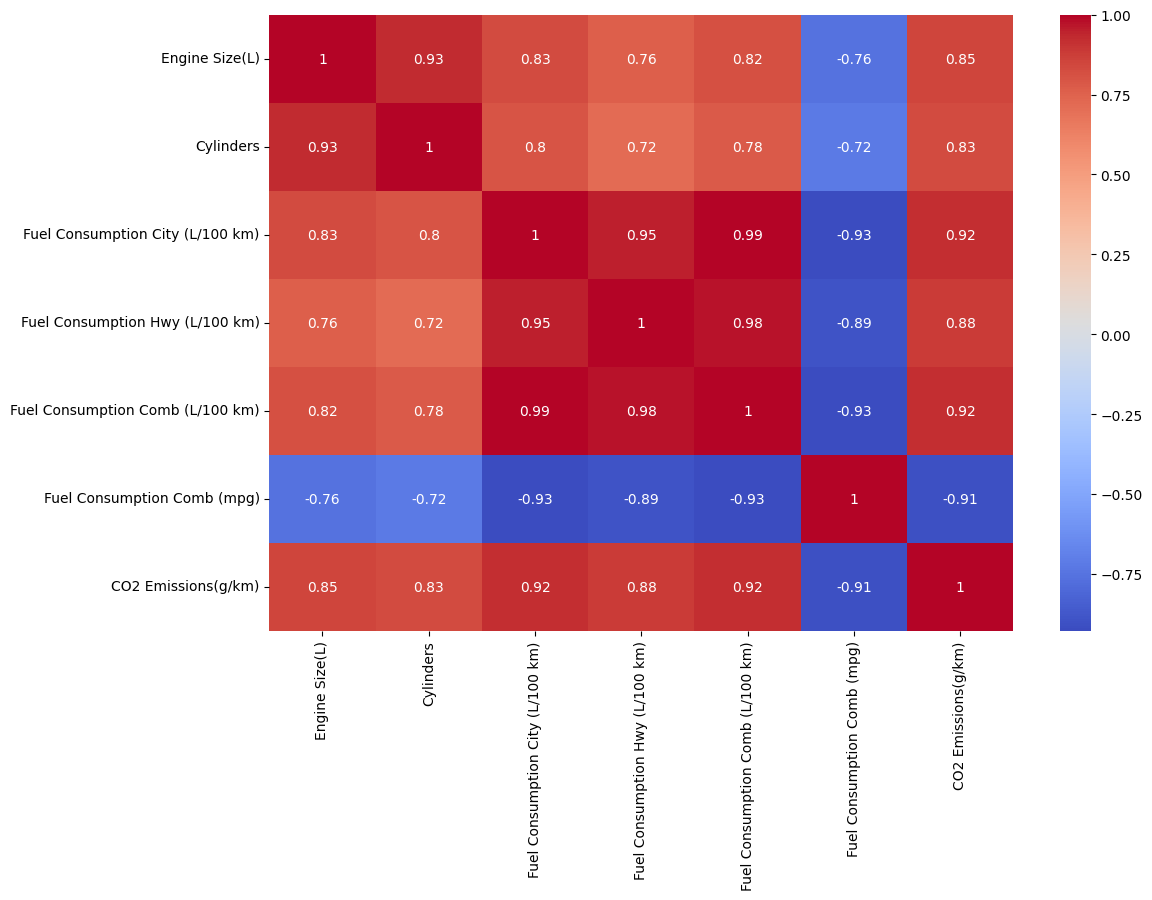

In [44]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [45]:
X_num = numeric_df.drop(columns=['CO2 Emissions(g/km)'])

vif_data = pd.DataFrame()
vif_data["Feature"] = X_num.columns
vif_data["VIF"] = [variance_inflation_factor(X_num.values, i)
                   for i in range(X_num.shape[1])]

print(vif_data)

                            Feature           VIF
0                    Engine Size(L)     54.498729
1                         Cylinders     79.205365
2  Fuel Consumption City (L/100 km)  28573.049517
3   Fuel Consumption Hwy (L/100 km)   9926.943589
4  Fuel Consumption Comb (L/100 km)  71236.232743
5       Fuel Consumption Comb (mpg)      7.025695


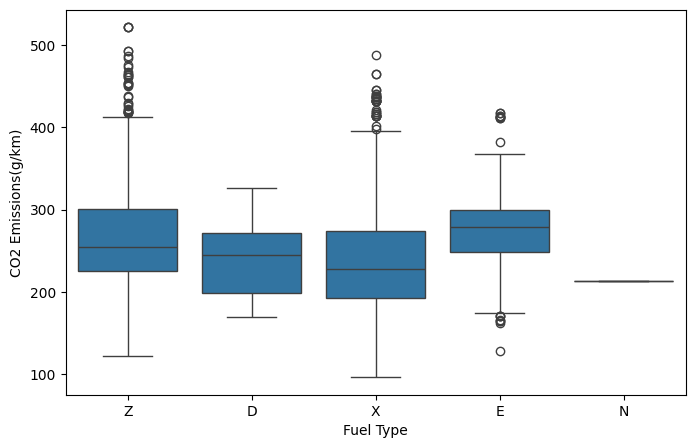

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Fuel Type',
            y='CO2 Emissions(g/km)',
            data=df)
plt.show()

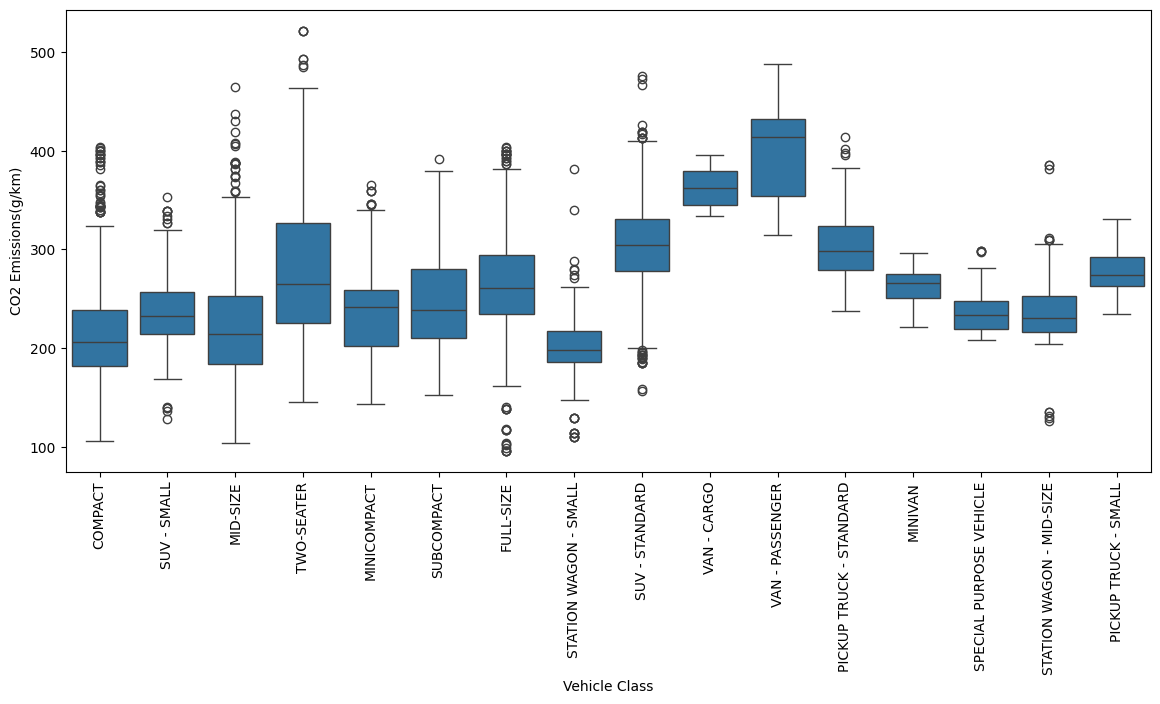

In [47]:
plt.figure(figsize=(14,6))
sns.boxplot(x='Vehicle Class',
            y='CO2 Emissions(g/km)',
            data=df)

plt.xticks(rotation=90)
plt.show()

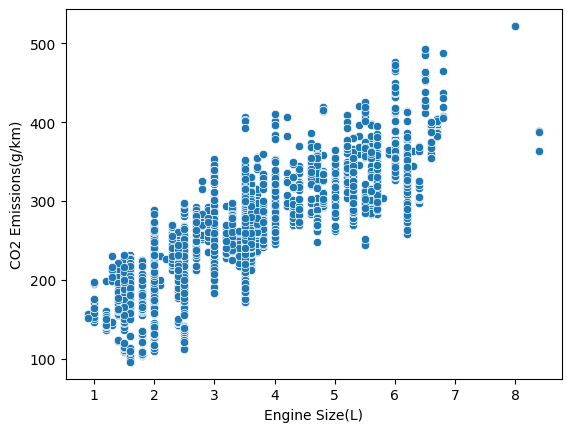

In [48]:
sns.scatterplot(
    x='Engine Size(L)',
    y='CO2 Emissions(g/km)',
    data=df
)
plt.show()

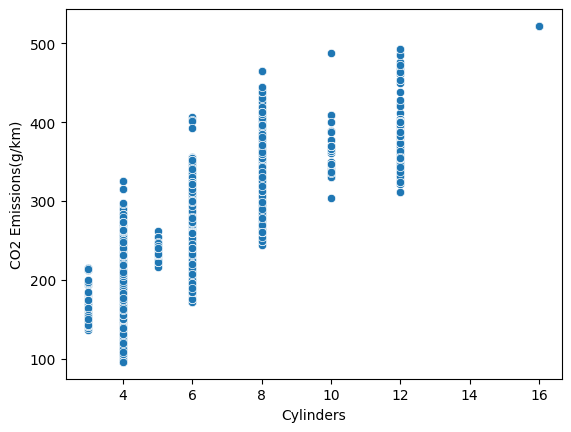

In [49]:
sns.scatterplot(
    x='Cylinders',
    y='CO2 Emissions(g/km)',
    data=df
)
plt.show()

In [50]:
print(df.columns.tolist())

['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']


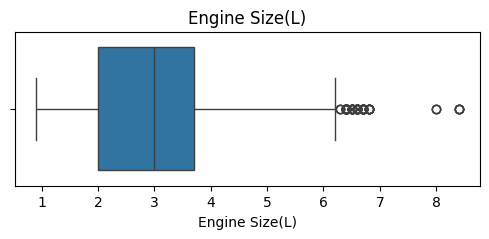

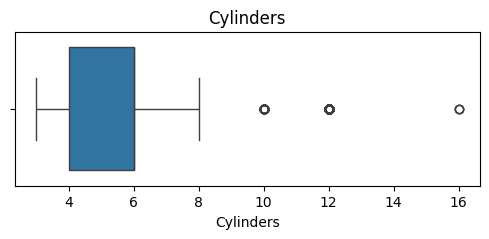

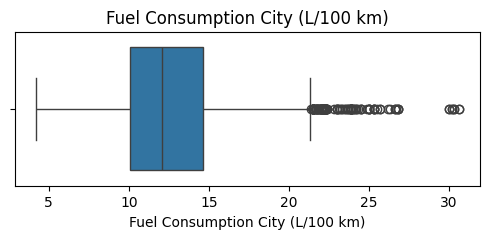

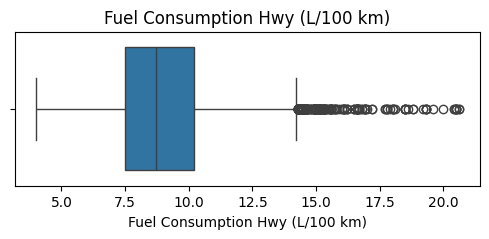

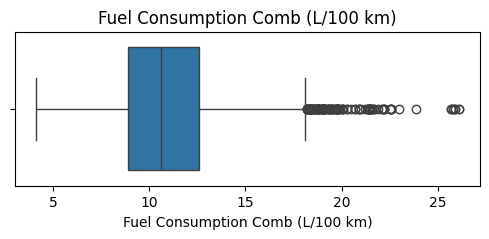

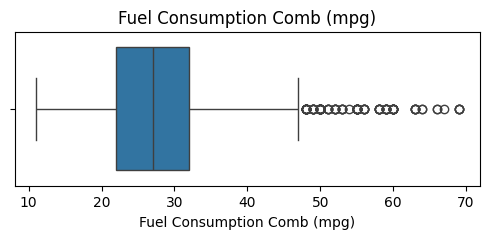

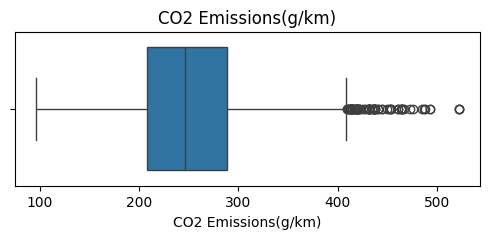

In [51]:
for col in numeric_df.columns:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [52]:
X = df.drop(columns=['CO2 Emissions(g/km)'])
y = df['CO2 Emissions(g/km)']

In [53]:
categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

In [54]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

In [55]:
Ridge()

Ridge()

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [57]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type'], dtype='object'))])),
                ('regressor', Ridge())])

In [58]:
y_pred = model.predict(X_test)

In [59]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.976302698582061
RMSE: 5.027128632494862
R2 Score: 0.9926526861075514


In [60]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(cv_scores.mean())

0.9927374100212599


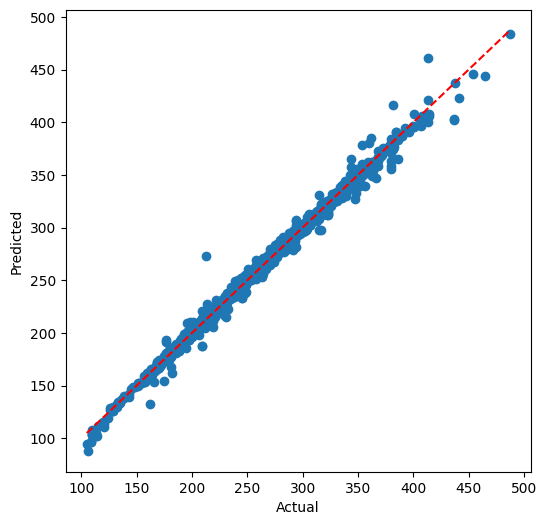

In [61]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

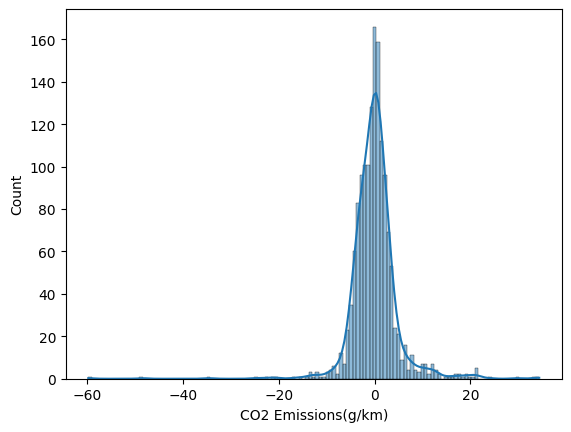

In [62]:
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.show()

In [63]:
feature_names = (
    numeric_cols.tolist() +
    list(model.named_steps['preprocessor']
         .named_transformers_['cat']
         .get_feature_names_out(categorical_cols))
)

coefficients = model.named_steps['regressor'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df.sort_values(by='Coefficient', ascending=False).head(10)

,Feature,Coefficient
2012,Fuel Type_D,47.194987
2,Fuel Consumption City (L/100 km),20.529733
2015,Fuel Type_Z,19.500487
4,Fuel Consumption Comb (L/100 km),18.847848
2014,Fuel Type_X,17.530228
790,Model_EXPRESS 3500 PASSENGER,16.616160
12,Make_BUGATTI,14.588052
975,Model_GT,13.968981
1032,Model_IONIQ,13.576032
1034,Model_IONIQ Blue,12.594869


Final Business Insights

Your conclusion section should discuss:

Strongest Factors

Likely:

fuel consumption,
engine size,
cylinders,
vehicle class.
Key Findings

Examples:

SUVs and high-engine vehicles emit substantially more CO₂.
Fuel efficiency is the strongest predictor.
Premium fuel vehicles often show higher emissions.
Compact and smaller vehicles are more environmentally efficient.
Recommendations

Examples:

Encourage smaller engine vehicles.
Improve fuel efficiency standards.
Promote hybrid/electric adoption.
Introduce stricter regulations for high-emission vehicle classes.